In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# this is the code to load the MNIST dataset
# it will need some time to run
from sklearn.datasets import fetch_openml
X, y = fetch_openml("Fashion-MNIST", version=1, return_X_y=True, as_frame=False)


In [3]:
print(X.shape, y.shape)

(70000, 784) (70000,)


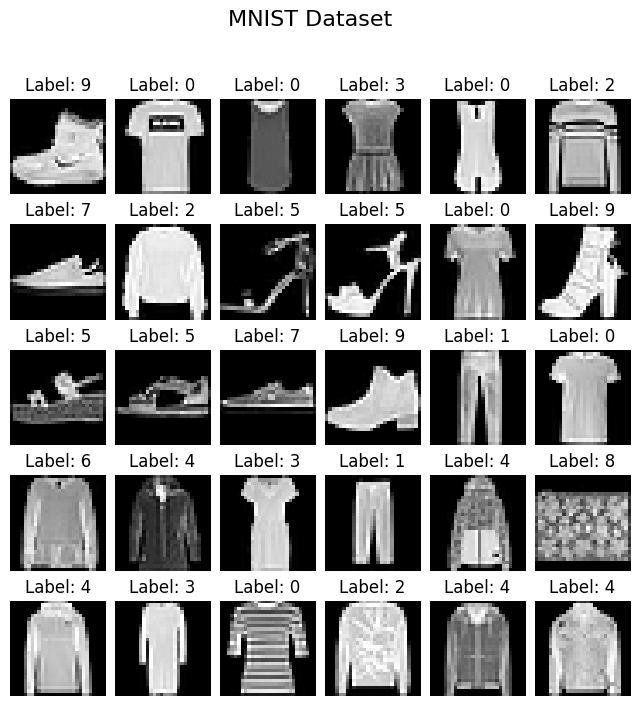

In [4]:

fig = plt.figure(figsize=(8, 8))
fig.suptitle("MNIST Dataset", fontsize=16)
fig.subplots_adjust(wspace=0.1, hspace=0.1)
for i in range(30):
    images = X[i].reshape(28, 28)
    ax = fig.add_subplot(5, 6, i + 1)
    ax.imshow(images, cmap="gray")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(46900, 784) (46900,)
(23100, 784) (23100,)


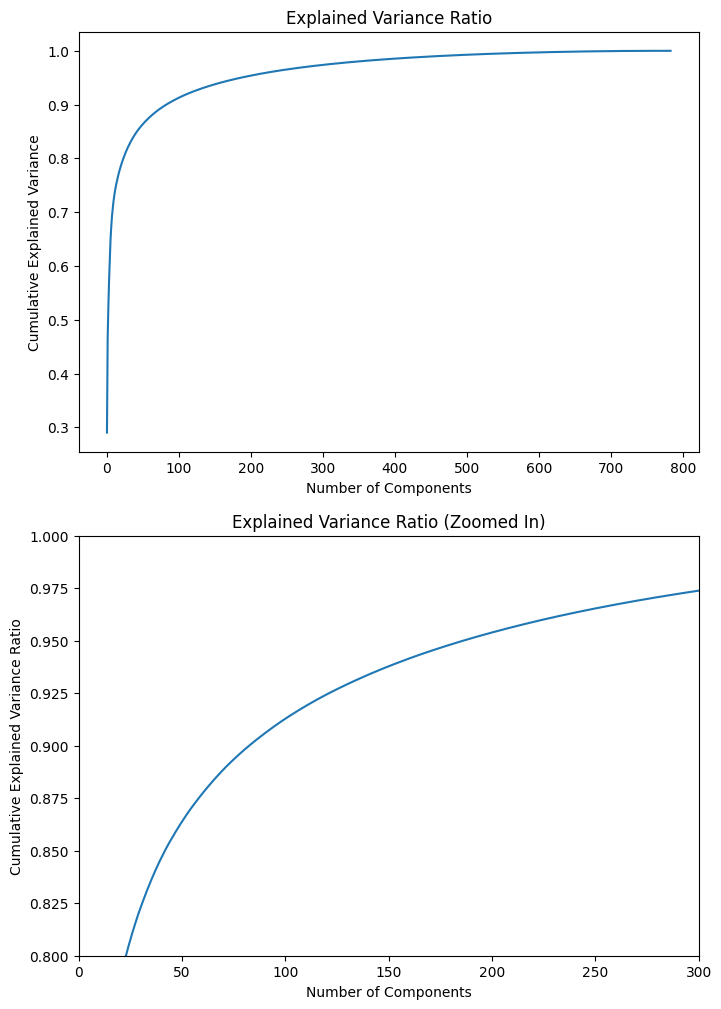

In [17]:
from sklearn.decomposition import PCA
pca = PCA(n_components=X.shape[1])
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

fig = plt.figure(figsize=(8, 12))
ax1 = plt.subplot(2, 1, 1)
ax1.plot(np.cumsum(pca.explained_variance_ratio_))
ax1.set_xlabel("Number of Components")
ax1.set_ylabel("Cumulative Explained Variance")
ax1.set_title("Explained Variance Ratio")

ax2 = plt.subplot(2, 1, 2)
ax2.plot(np.cumsum(pca.explained_variance_ratio_))
ax2.set_xlabel("Number of Components")
ax2.set_ylabel("Cumulative Explained Variance Ratio")
ax2.set_title("Explained Variance Ratio (Zoomed In)")
ax2.set_xlim(0, 300)
ax2.set_ylim(0.8, 1)
ax2.grid()

plt.grid()
plt.show()

In [7]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import time 

#######################
time_now = time.time()
#######################

"""
this works but it takes a long time to run, so I will not run it in the notebook
svm_clf = SVC(kernel="rbf", random_state=42)
svm_clf.fit(X_train_pca, y_train)
y_pred = svm_clf.predict(X_test_pca)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
"""
# linear svm is much faster to train, but it may not perform as well as the rbf kernel
from sklearn.svm import LinearSVC

# I will try linear svm with 100 components, which explains about 90% of the variance
pca = PCA(n_components=200)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

#######################
time_PCA = time.time()
#######################

#linear svm
linear_svm_clf = LinearSVC(random_state=42)
linear_svm_clf.fit(X_train_pca, y_train)
y_pred_linear = linear_svm_clf.predict(X_test_pca)

#######################
time_linear_svm = time.time()
#######################

print(classification_report(y_test, y_pred_linear))
print(f"Time taken for PCA: {time_PCA - time_now}")
print(f"Time taken for Linear SVM: {time_linear_svm - time_PCA}")

              precision    recall  f1-score   support

           0       0.78      0.82      0.80      2299
           1       0.98      0.96      0.97      2345
           2       0.75      0.75      0.75      2287
           3       0.84      0.88      0.86      2342
           4       0.74      0.79      0.77      2289
           5       0.94      0.94      0.94      2348
           6       0.67      0.54      0.60      2325
           7       0.92      0.93      0.92      2287
           8       0.92      0.95      0.94      2224
           9       0.95      0.95      0.95      2354

    accuracy                           0.85     23100
   macro avg       0.85      0.85      0.85     23100
weighted avg       0.85      0.85      0.85     23100

Time taken for PCA: 0.8592243194580078
Time taken for Linear SVM: 578.1722798347473


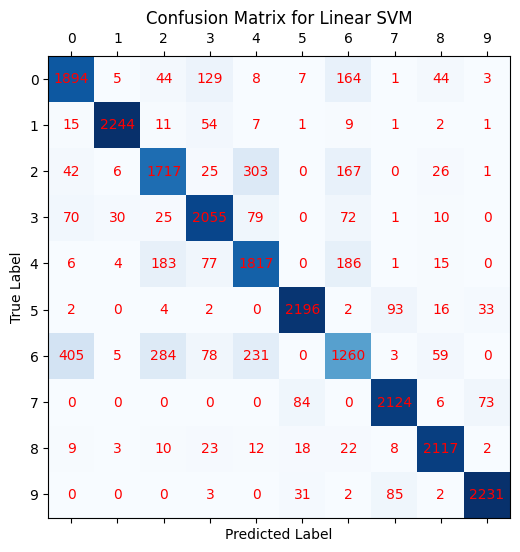

In [8]:
# confusion matrix for linear svm in matplotlib
ax = plt.figure(figsize=(8, 6)).gca()
ax.matshow(confusion_matrix(y_test, y_pred_linear), cmap=plt.cm.Blues)
for i in range(10):
    for j in range(10):
        ax.text(j, i, str(confusion_matrix(y_test, y_pred_linear)[i, j]),
                ha="center", va="center", color="red")

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix for Linear SVM")
size = len(np.unique(y_test))
ax.set_xticks(np.arange(size))
ax.set_yticks(np.arange(size))
plt.show()
